<a href="https://colab.research.google.com/github/pachterlab/cellmender/blob/main/intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# try:
#     from cellmender import denoise_count_matrix
# except ImportError:
#     print("cellmender not found, installing...")
#     !pip install -U -q cellmender[analysis]

In [2]:
import os
import anndata as ad
import scanpy as sc
from cellmender import denoise_count_matrix
import cellmender.utils as cm_utils

cellmender_dir = os.path.dirname(os.path.abspath(""))

# Intro

### Dataset: PBMC 1K from healthy donor (10x Genomics): https://www.10xgenomics.com/datasets/human-pbmc-from-a-healthy-donor-1-k-cells-v-2-2-standard-4-0-0

In [3]:
data_dir = os.path.join(cellmender_dir, "notebooks", "data", "pbmc1k")
os.makedirs(data_dir, exist_ok=True)

out_dir = os.path.join(cellmender_dir, "notebooks", "output", "pbmc1k")
os.makedirs(out_dir, exist_ok=True)

adata_raw_path = os.path.join(data_dir, "sc5p_v2_hs_PBMC_1k_raw_feature_bc_matrix.h5")
if not os.path.exists(adata_raw_path):
    !curl -L -o "{adata_raw_path}" "https://cf.10xgenomics.com/samples/cell-vdj/4.0.0/sc5p_v2_hs_PBMC_1k/sc5p_v2_hs_PBMC_1k_raw_feature_bc_matrix.h5"

adata_raw = sc.read_10x_h5(adata_raw_path)
adata_raw = adata_raw[:, :5000].copy()  # keep only 5000 genes
adata_raw.var_names_make_unique()
expected_cells = 1_200  # slight overestimate since we will do empty droplet removal
model_pkl = "Immune_All_High.pkl"

adata_cellmender_path = os.path.join(out_dir, "adata_cellmender.h5ad")

/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


## Knee plot - use this output to estimate cs_empty_threshold

UMI cutoff for expected cells (1200): 4.00


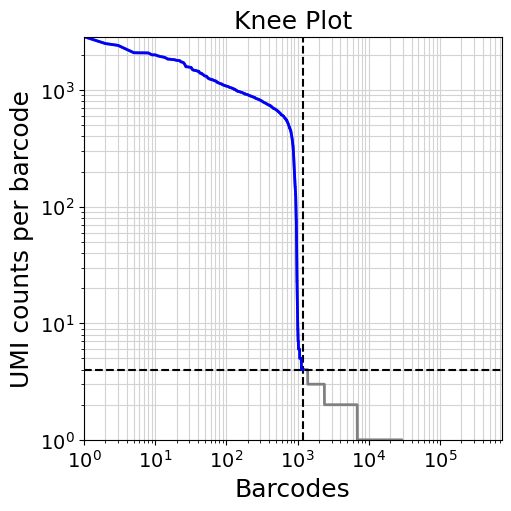

In [4]:
cm_utils.knee_plot(adata_raw, expected_cells=expected_cells, out_path=os.path.join(out_dir, "knee_plot.png"))

## Determine cell types - here, we use celltypist, but you can use any method you like

In [5]:
adata = cm_utils.determine_cell_types(adata_raw, model_pkl=model_pkl, filter_empty=True, expected_cells=expected_cells, verbose=2)

13:52:56 - INFO - Filtering empty droplets using column 'is_empty' in adata.obs. If this column is not present, it will be inferred using method 'celltypist' with umi_cutoff=None and expected_cells=1200.
13:52:56 - INFO - 'is_empty' column not found in adata.obs. Inferring empty droplets using method 'celltypist' with umi_cutoff=None and expected_cells=1200.


13:52:56 - INFO - Running cell type annotation using CellTypist with model_pkl=Immune_All_High.pkl. This may take some time depending on the size of the dataset and the model used.
/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv
📂 Storing models in /home/jrich/.celltypist/data/models
⏩ Skipping [1/58]: Immune_All_Low.pkl (file exists)
⏩ Skipping [2/58]: Immune_All_High.pkl (file exists)
⏩ Skipping [3/58]: Adult_COVID19_PBMC.pkl (file exists)
⏩ Skipping [4/58]: Adult_CynomolgusMacaque_Hippocampus.pkl (file exists)
⏩ Skipping [5/58]: Adult_Human_MTG.pkl (file exists)
⏩ Skipping [6/58]: Adult_Human_PancreaticIslet.pkl (file exists)
⏩ Skipping [7/58]: Adult_Human_PrefrontalCortex.pkl (file exists)
⏩ Skipping [8/58]: Adult_Human_Skin.pkl (file exists)
⏩ Skipping [9/58]: Adult_Human_Vascular.pkl (file exists)
⏩

## Run cellmender

In [ ]:
%time
adata_cellmender = denoise_count_matrix(adata, adata_out=adata_cellmender_path, max_iter=40, beta=0.3, eps=1e-9, empty_droplet_method="threshold", expected_cells=expected_cells, cell_ambient_fraction=0.01, verbose=2, log_file=os.path.join(out_dir, "cellmender.log"))
# adata_cellmender = ad.read_h5ad(adata_cellmender_path)

13:54:27 - INFO - Added 'ambient_fraction' to adata.var.
13:54:27 - INFO - adata.uns does not have 'celltype_profile'. Inferring cell type profiles using infer_celltype_profile().
13:54:27 - INFO - Number of parameters in the cellmender model: 26,389 (p_k: 25,000, alpha_i: 1,385, m_k: 4)
13:54:27 - INFO - adata.obs does not have 'cell_ambient_fraction'. Setting to `cell_ambient_fraction` argument.


CPU times: user 22 μs, sys: 0 ns, total: 22 μs
Wall time: 42.9 μs
Logging to /home/jrich/Desktop/cellmender/notebooks/output/pbmc1k/cellmender.log


ValueError: matmul: dimension mismatch with signature (n,k=5000),(k=1385,m)->(n,m)

## Filter empty droplets

In [ ]:
adata_cellmender = adata_cellmender[~adata_cellmender.obs["is_empty"]].copy()

## Basic analysis

In [ ]:
print(f"Raw:\n{adata_raw}\n\n")
print(f"cellmender:\n{adata_cellmender}\n\n")
print("Fraction of cells retained after cellmender:", adata_cellmender.n_obs / adata_raw.n_obs)

In [ ]:
upset_data_dict = {
    "Raw": set(adata_raw.obs_names),
    "cellmender": set(adata_cellmender.obs_names),
}

_ = cm_utils.make_upset_plot(upset_data_dict, title="Cells Retained After CellMender", out_path=os.path.join(out_dir, "cells_retained_upset.png"))

In [ ]:
cm_utils.plot_matrix_scatterplot(adata_raw, adata_cellmender, scale="log", x_axis="raw", y_axis="cellmender", out_path=os.path.join(out_dir, "raw_vs_cellmender_expression_scatterplot.png"), show=True)